In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scripts.database import *


Database creation

In [12]:
create_database()

database_validation()

1. DATABASE STRUCTURE CREATION...
✓ TABLES CREATED SUCCESSFULLY
2. FILLING OUT DIRECTORIES...
✓ DIRECTORY visitor_types WAS FILLED WITH 3 ENTRIES
3. DATA LOADING AND PROCESSING...
✓ SESSIONS LOADED: 12330
✓ SESSIONS METRICS LOADED: 12330
4. INDEXES CREATION FOR OPTIMIZATION...
✓ INDEXES WERE CREATED
5. DATABASE SAVING AND CLOSING...
✓ DATABASE WAS CREATED SUCCESSFULLY AND IS READY TO USE
6. DATA INTEGRITY CHECK...
SOME STATISTICS FROM DB:
Total quantity of sessions:
12330
Total metrics for sessions:
12330
Total success sessions in %:
15.47
Total sessions without purchases in %:
84.53
Total returning visitors in %:
85.57
Total new visitors in %:
13.74
Purchases by visitor types:
('New_Visitor', 422, 22.12)
('Other', 16, 0.84)
('Returning_Visitor', 1470, 77.04)
7. ANALYTICAL QUERIES...
Top 3 months with purchases:
  month: Nov | purchases: 760
  month: May | purchases: 365
  month: Dec | purchases: 216
Top 3 browsers:
  browser: 2 | session_counts: 7961
  browser: 1 | session_counts: 246

In [13]:
df = load_data_from_db()

print(f"DF shape: rows - {df.shape[0]}, columns - {df.shape[1]}")

print('DF columns:', df.columns.tolist(), sep="\n")

print('Check empty values:', df.isna().sum(), sep="\n")

print(df.info())

num_cols = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]
cat_cols = [
    "Month",
    "VisitorType",
    "Weekend",
    "Browser",
    "OperatingSystems",
    "Region",
    "TrafficType"
]

# check statistics for numeric columns
print(df[num_cols].describe().T)

DF shape: rows - 12330, columns - 18
DF columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']
Check empty values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   C

Target variable analysis

Revenue
0    10422
1     1908
Name: count, dtype: int64


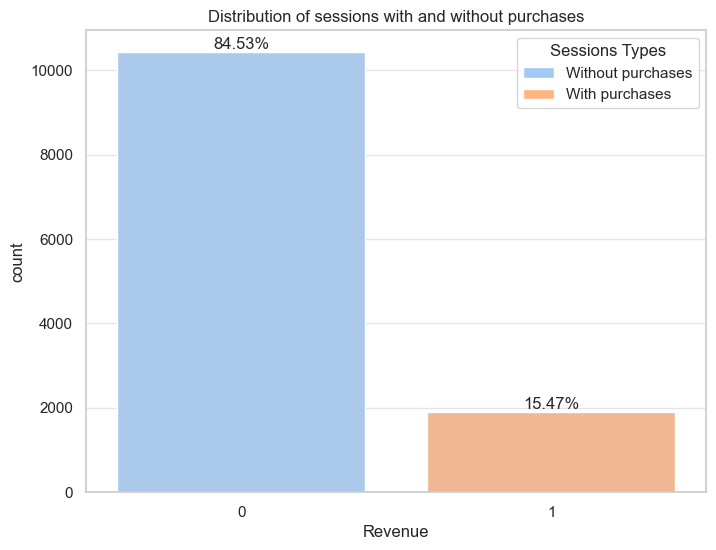

In [14]:
# check number of classes
print(df['Revenue'].value_counts())

sns.set_theme(
    style="whitegrid",
    palette="pastel",
)

plt.figure(figsize=(8,6))
ax = sns.countplot(
    data=df,
    x='Revenue',
    palette=[sns.color_palette("pastel").as_hex()[0], sns.color_palette("pastel").as_hex()[1]],
    hue='Revenue',
    legend=False,
)

for container in ax.containers:
    labels = [f"{val / len(df) * 100:.2f}%" for val in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="edge")

ax.legend(
    handles=[
        Patch(
            facecolor=sns.color_palette("pastel").as_hex()[0],
            label="Without purchases",
        ),
        Patch(
            facecolor=sns.color_palette("pastel").as_hex()[1],
            label="With purchases",
        ),
    ],
    title='Sessions Types'
)

plt.title('Distribution of sessions with and without purchases')
plt.show()

Distribution of numeric features

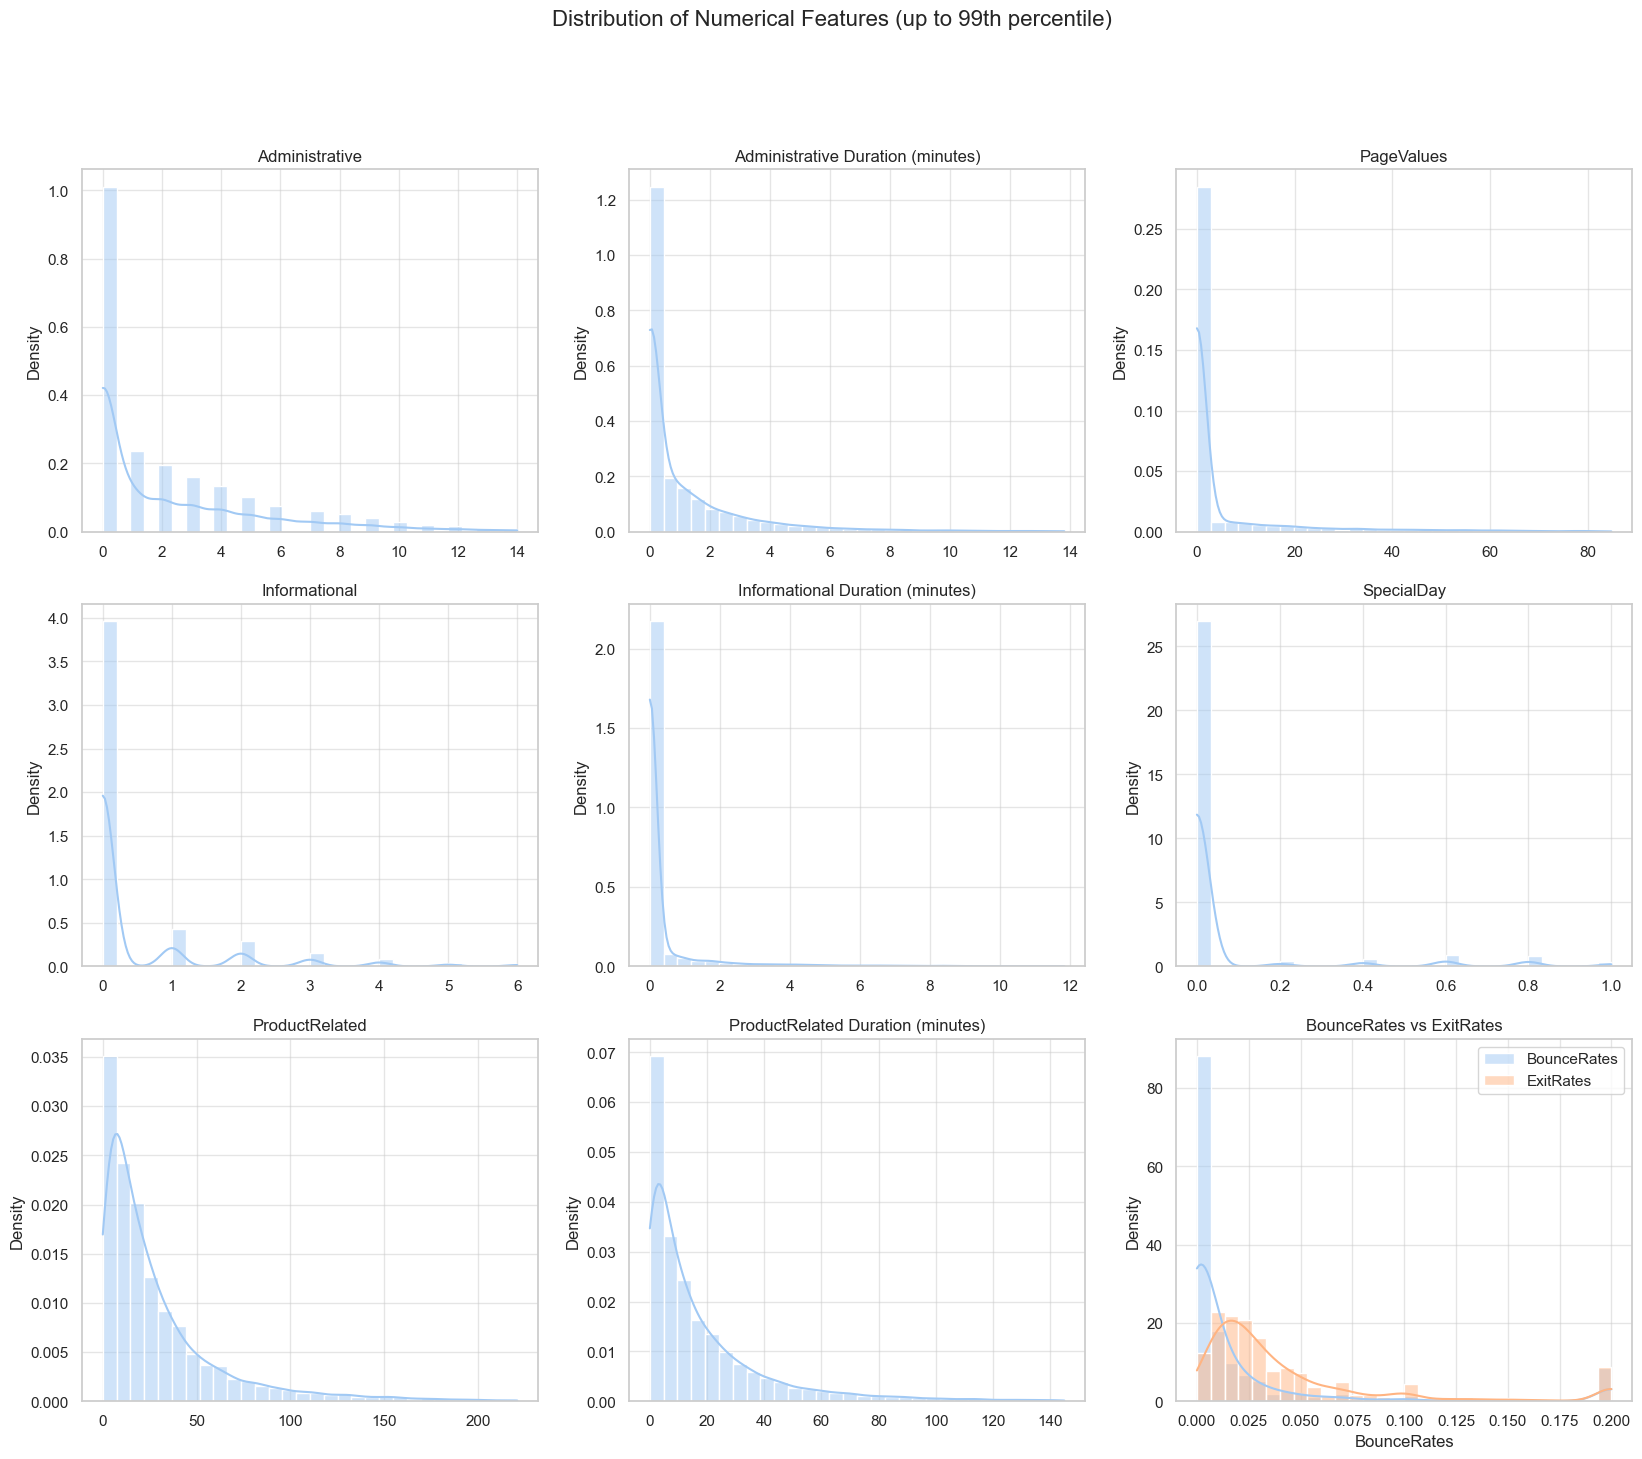

In [15]:
eda_df = df.copy()

# convert seconds into minutes
duration_cols = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration"
]

for col in duration_cols:
    eda_df[col] = eda_df[col] / 60

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(20, 16)
)

axes = axes.flatten()

sep_plots = [
    "Administrative",
    "Administrative_Duration",
    "PageValues",
    "Informational",
    "Informational_Duration",
    "SpecialDay",
    "ProductRelated",
    "ProductRelated_Duration"
]

join_plots = ["BounceRates", "ExitRates"]

for ax, col in zip(axes[:8], sep_plots):
    # limit the tail to the 99th percentile to make plots more readable
    upper = eda_df[col].quantile(0.99)

    sns.histplot(
        eda_df.loc[eda_df[col] <= upper, col],
        bins=30,
        kde=True,
        stat="density",
        ax=ax
    )

    title = col.replace("_", " ")

    if "Duration" in col:
        title += " (minutes)"

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("")

# BounceRates + ExitRates
for col in join_plots:
    sns.histplot(
        eda_df[col],
        bins=30,
        kde=True,
        stat="density",
        alpha=0.5,
        label=col,
        ax=axes[8]
    )

axes[8].set_title("BounceRates vs ExitRates")
axes[8].legend()

plt.suptitle(
    "Distribution of Numerical Features (up to 99th percentile)",
    fontsize=16
)

plt.show()

Outliers

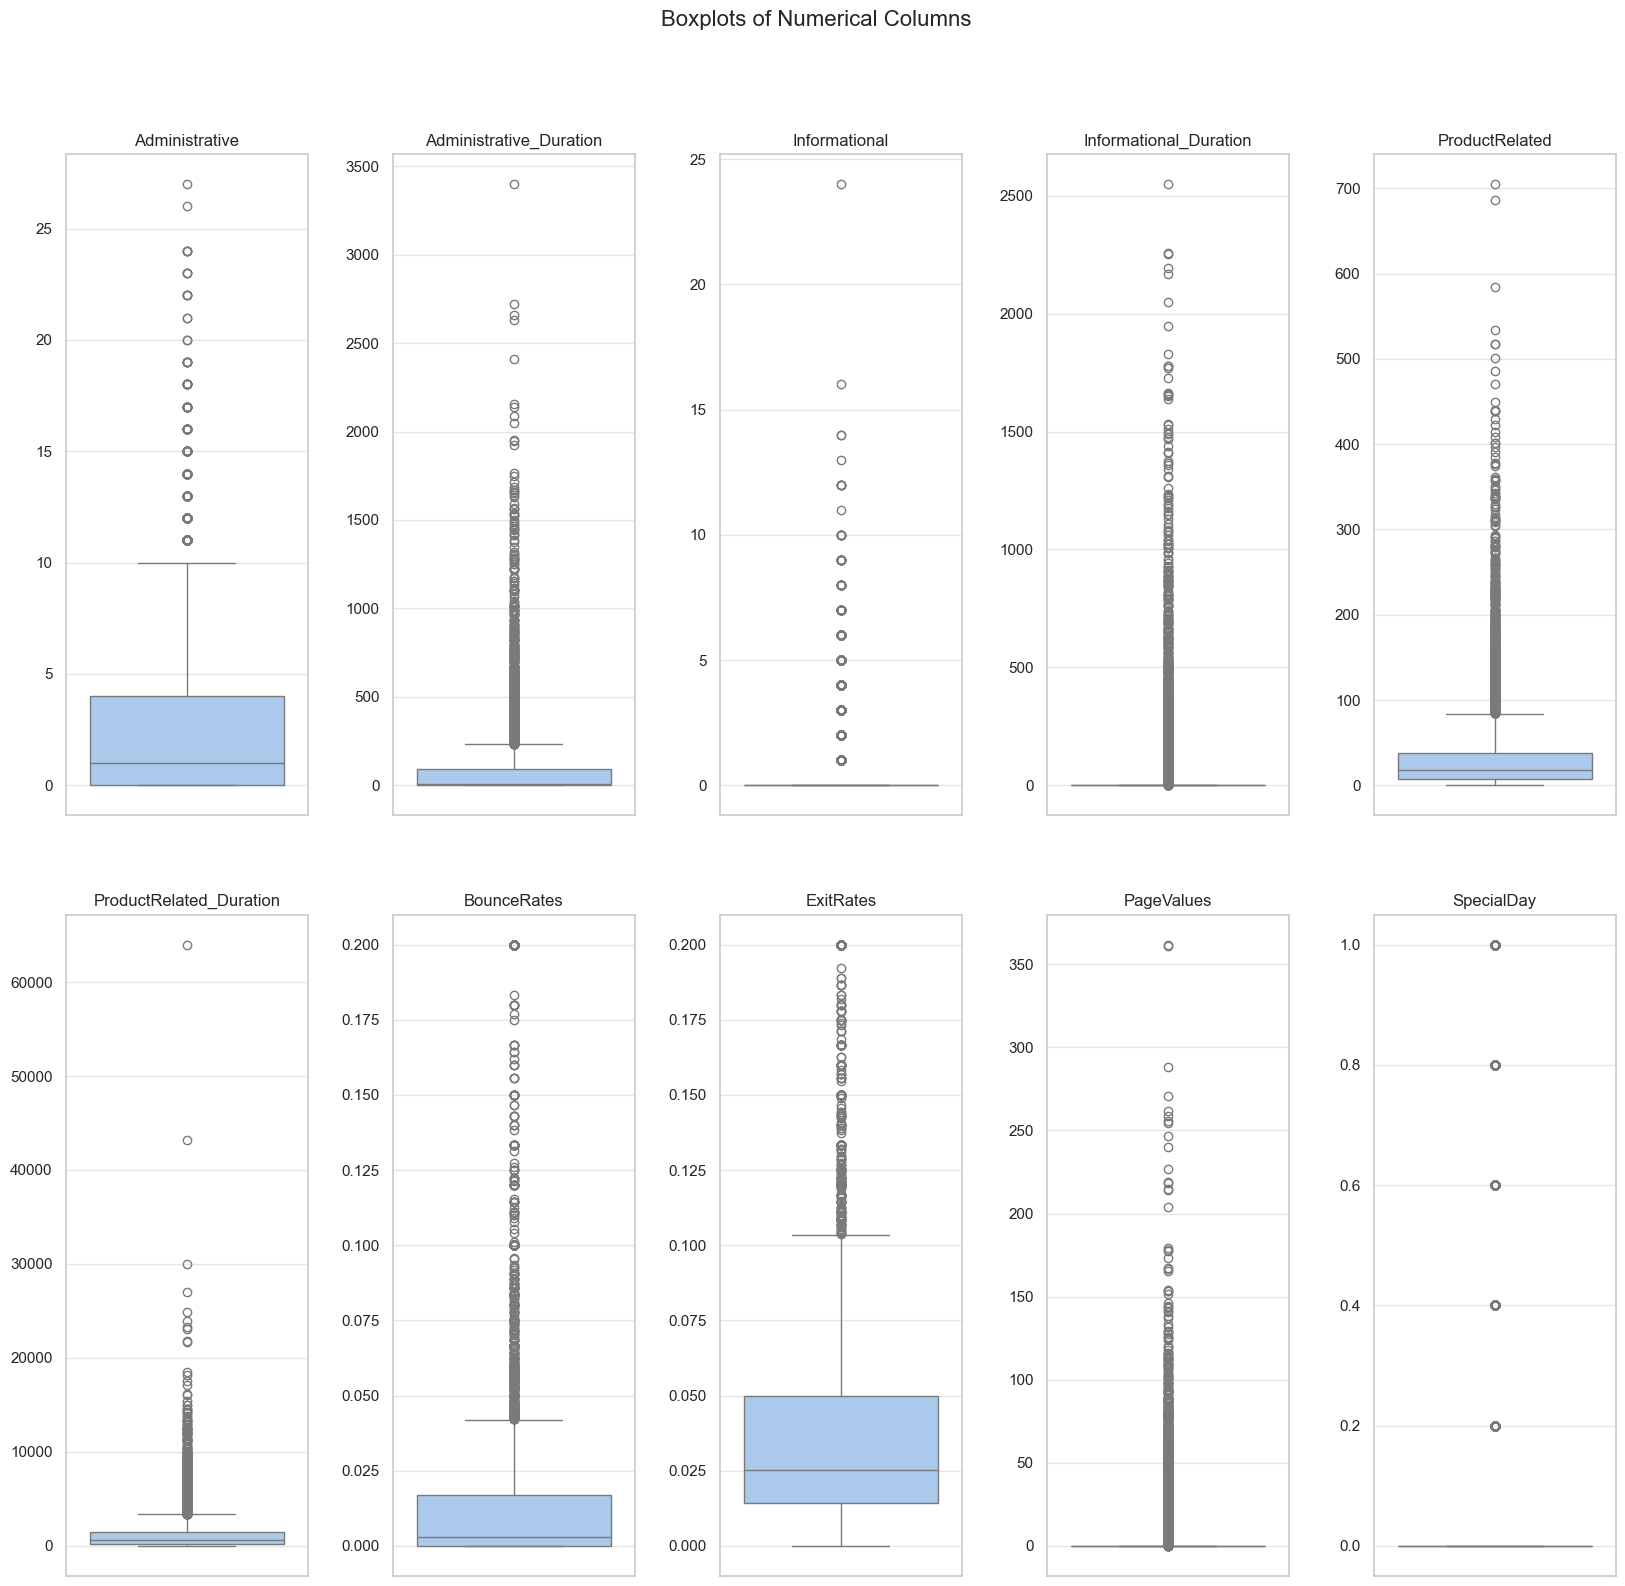

In [16]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(20, 18)
)
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(
        df[col],
        ax=ax
    )
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.title(col)

plt.suptitle('Boxplots of Numerical Columns', fontsize=16, y=0.98)
fig.subplots_adjust(
    hspace=0.15,
    wspace=0.35,
    top=0.90
)
plt.show()

Features correlations

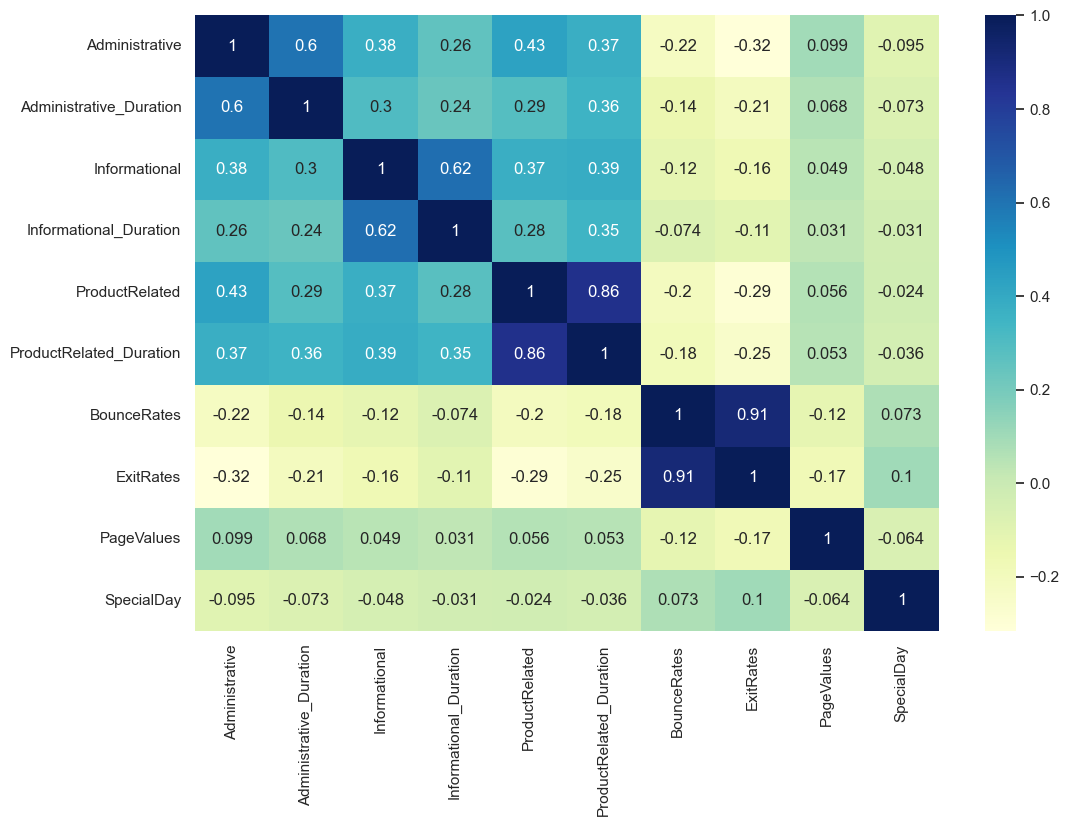

In [17]:
corr = df[num_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.show()

Comparison of the distribution of numerical features by classes

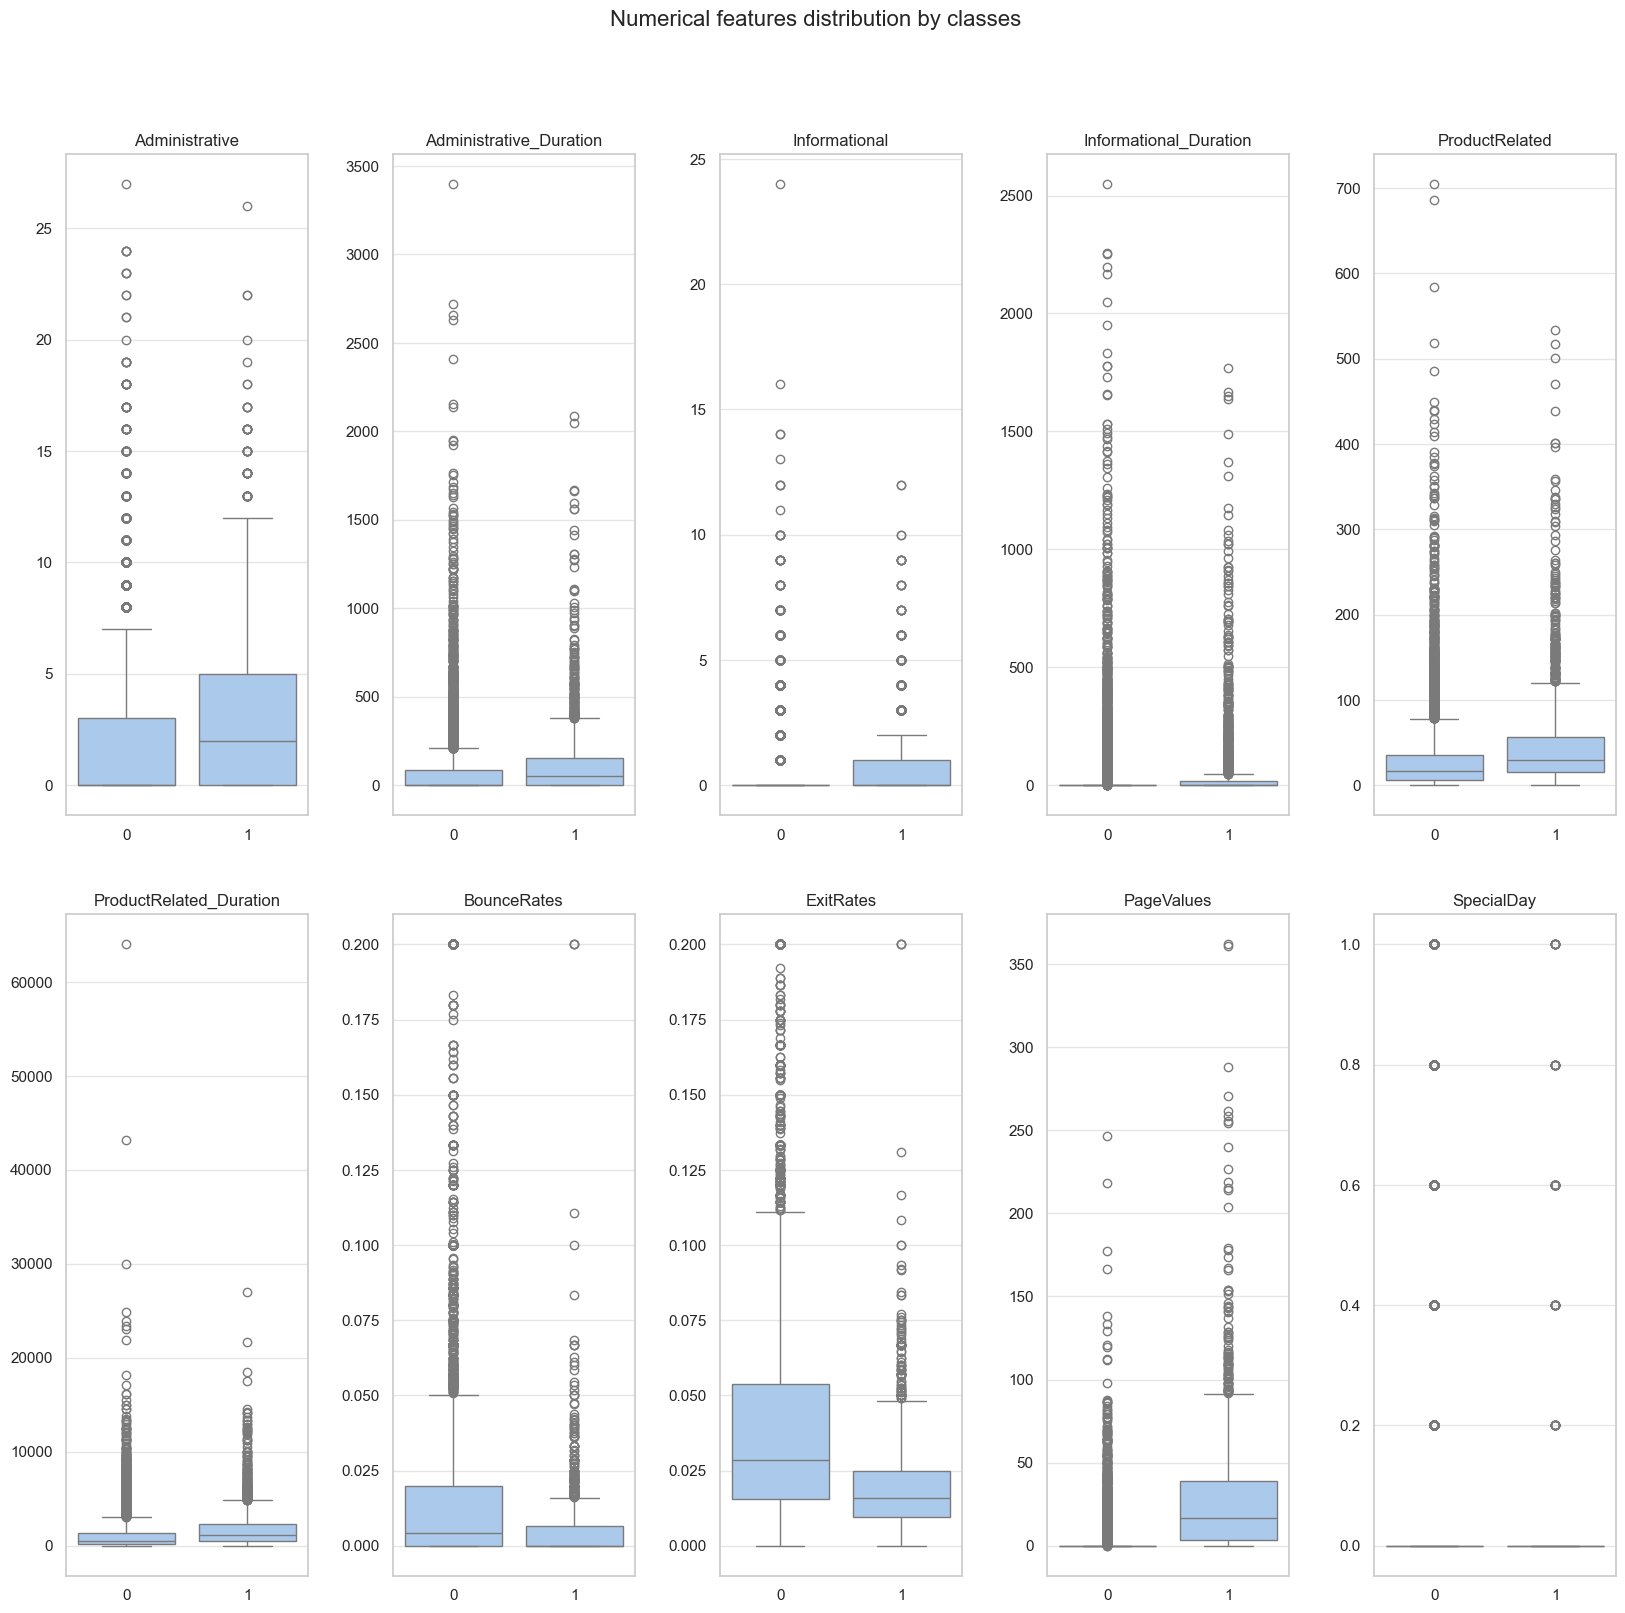

In [18]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(20, 18)
)
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="Revenue", y=col, ax=ax)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.title(col)

plt.suptitle('Numerical features distribution by classes', fontsize=16, y=0.98)
fig.subplots_adjust(
    hspace=0.15,
    wspace=0.35,
    top=0.90
)
plt.show()

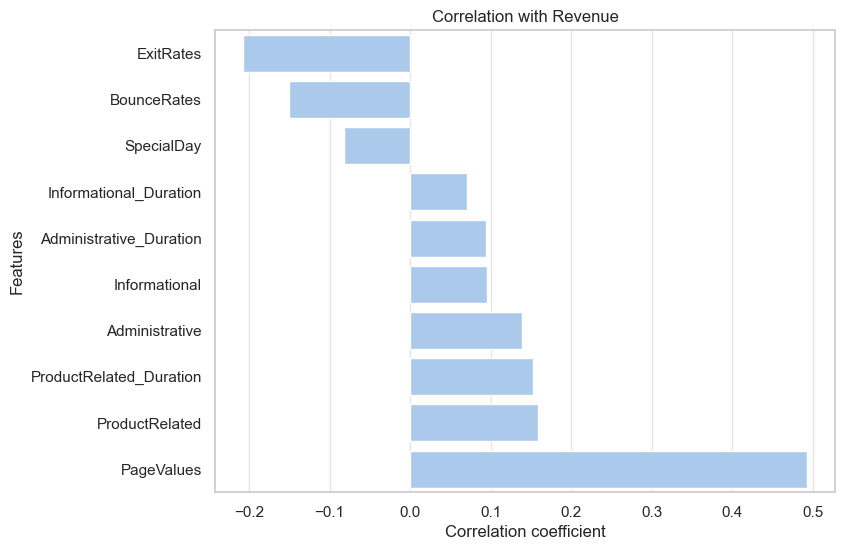

In [25]:
target_corr = (
    df[num_cols]
    .corrwith(df["Revenue"])
    .sort_values()
)

plt.figure(figsize=(8, 6))

sns.barplot(
    x=target_corr.values,
    y=target_corr.index
)

plt.title("Correlation with Revenue")
plt.xlabel("Correlation coefficient")
plt.ylabel("Features")

plt.show()

Categorical features analysis

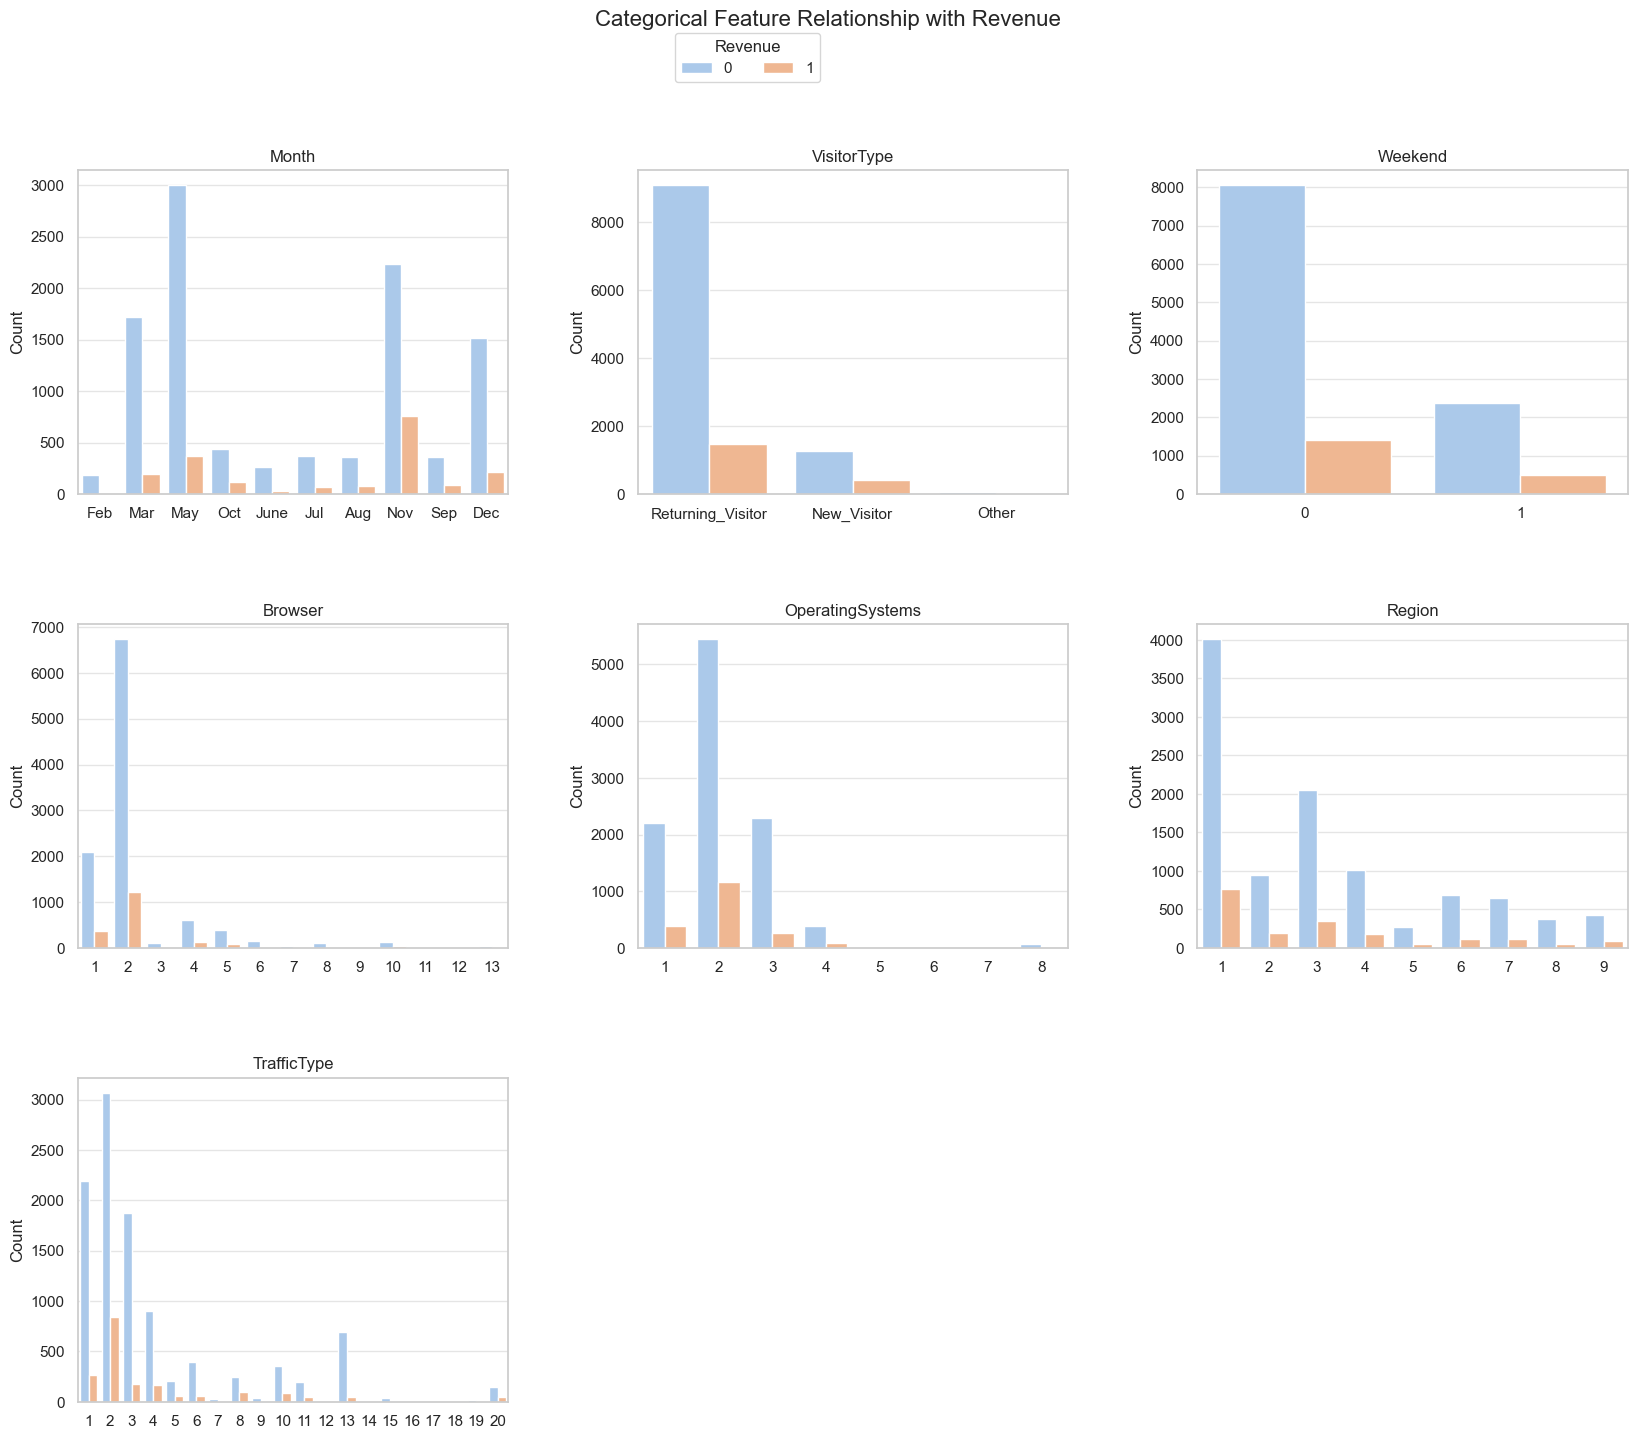

In [19]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(20, 16)
)

axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(
        data=df,
        x=col,
        hue="Revenue",
        ax=ax
    )

    ax.set_title(col, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

    # # rotate x-ticks подписей для признаков с большим числом категорий
    # ax.tick_params(axis="x", rotation=45)

    # remove local legends
    ax.legend_.remove()

# hide extra subplots
for ax in axes[len(cat_cols):]:
    ax.axis("off")

# common legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Revenue",
    loc="center right",
    ncol=2,
    bbox_to_anchor=(0.5, 0.95)
)

fig.suptitle(
    "Categorical Feature Relationship with Revenue",
    fontsize=16,
    y=0.98
)

fig.subplots_adjust(
    hspace=0.4,
    wspace=0.3,
    top=0.88
)

plt.show()

Categorical features conversion into revenue

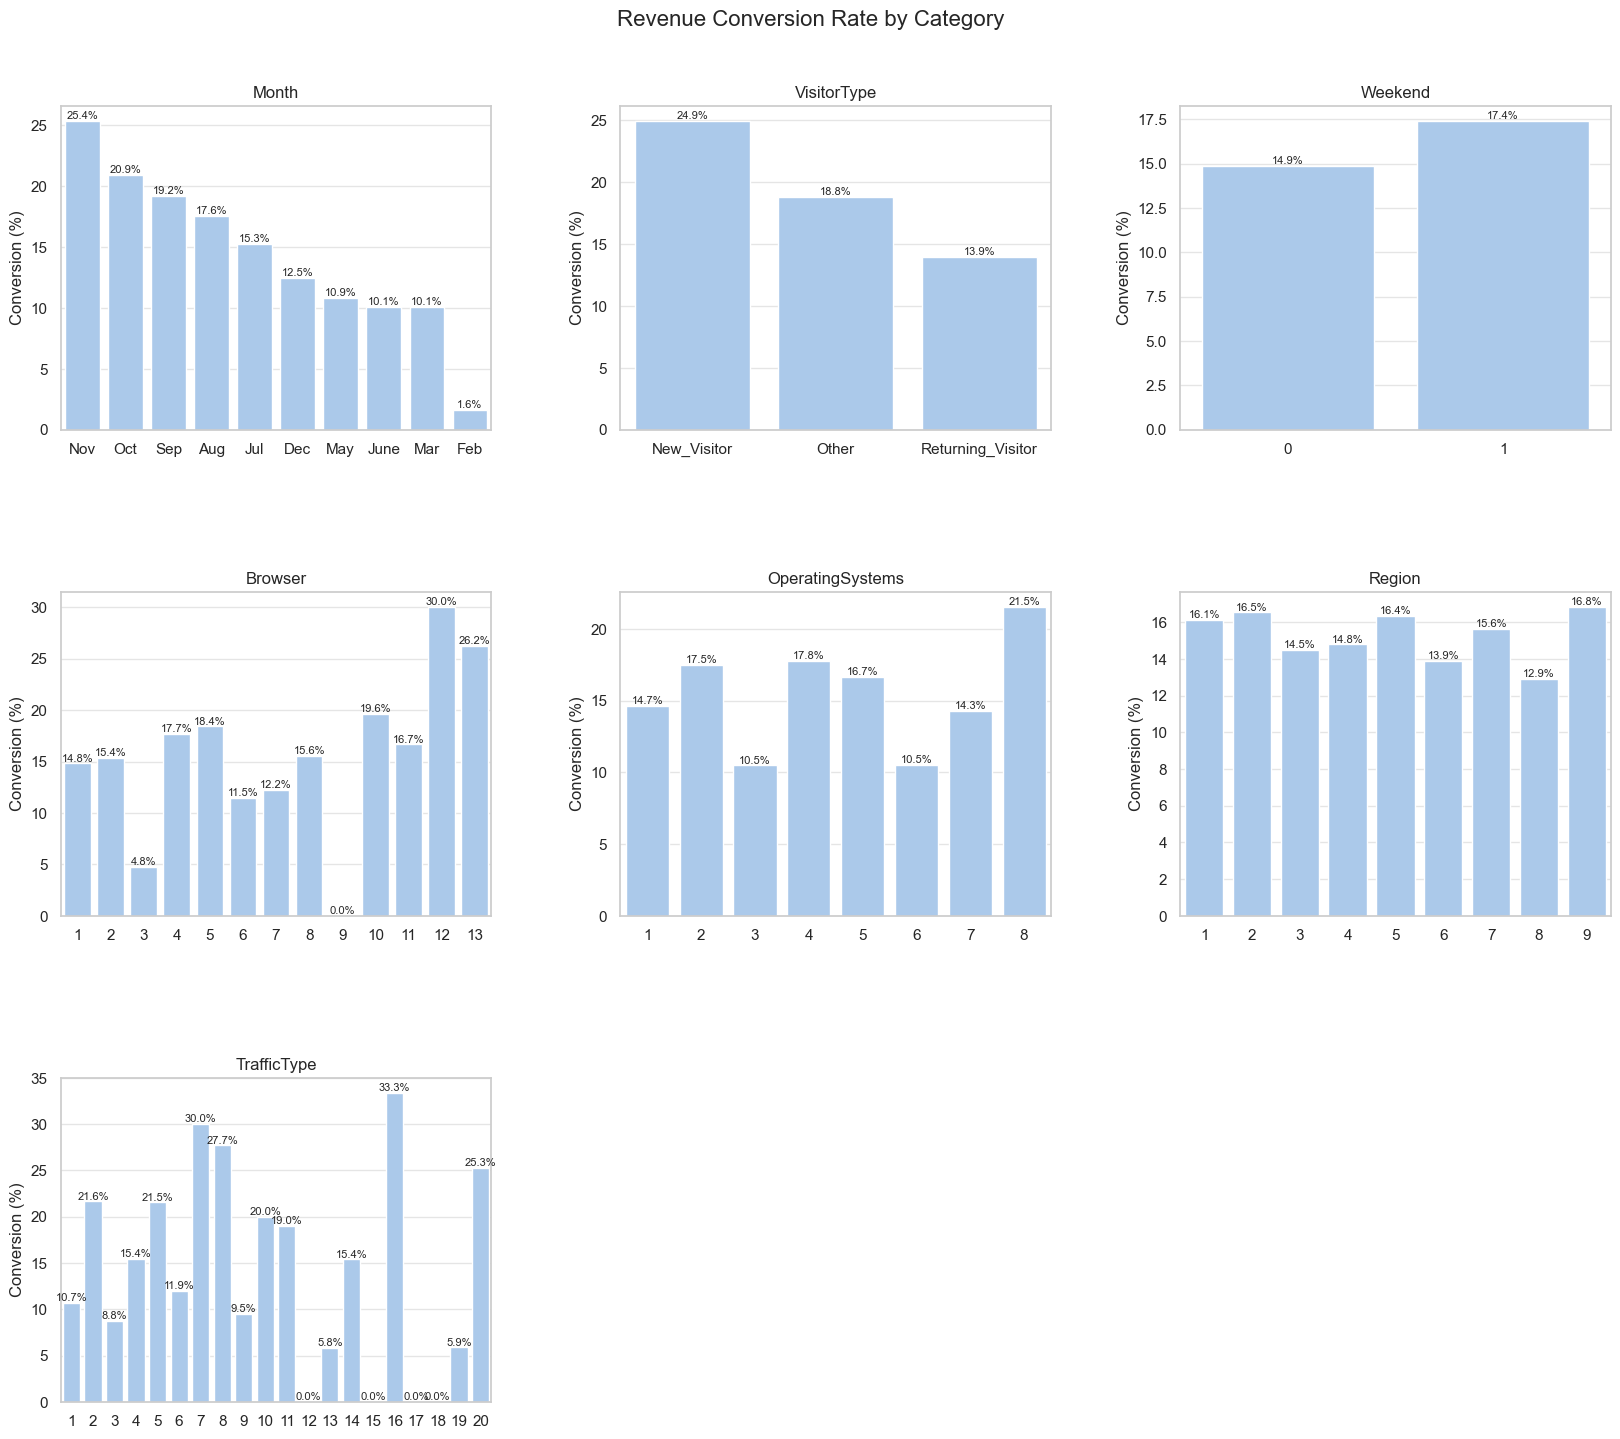

In [20]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(20, 16)
)

axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    conversion = (
        df.groupby(col, as_index=False)["Revenue"]
        .mean()
        .sort_values("Revenue", ascending=False)
    )

    conversion["Revenue"] *= 100

    sns.barplot(
        data=conversion,
        x=col,
        y="Revenue",
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            fontsize=8
        )

    ax.set_title(
        col.replace("_", " "),
        fontsize=12
    )

    ax.set_ylabel("Conversion (%)")
    ax.set_xlabel("")

# hide empty axes
for ax in axes[len(cat_cols):]:
    ax.axis("off")

fig.suptitle(
    "Revenue Conversion Rate by Category",
    fontsize=16,
    y=0.98
)

fig.subplots_adjust(
    hspace=0.5,
    wspace=0.3,
    top=0.92
)

plt.show()